# EDA - Gym Churn Predictor

Este notebook documenta a analise exploratoria da base `gym_churn_us.csv` para a entrega da Semana 5 do projeto de predicao de churn.

Objetivos:

- carregar a base de clientes;
- verificar qualidade dos dados;
- limpar duplicados e nulos;
- visualizar a distribuicao de churn;
- comparar clientes que ficaram versus clientes que cancelaram;
- justificar as features usadas no modelo preditivo.

## 1. Importacao de bibliotecas e configuracao

O notebook usa `pandas` para manipulacao dos dados e `matplotlib` para graficos simples. A base deve estar em `dataset/gym_churn_us.csv` na raiz do projeto.

In [24]:
import importlib.util
import subprocess
import sys

required_packages = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
}

missing_packages = [
    package
    for package, module in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

print(f"Kernel Python: {sys.executable}")
print("Dependencias prontas para a EDA.")

Kernel Python: /Library/Developer/CommandLineTools/usr/bin/python3
Dependencias prontas para a EDA.


In [25]:
import numpy as np

In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FEATURES = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Age",
    "Contract_period",
    "Month_to_end_contract",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
    "Group_visits",
    "Promo_friends",
    "Partner",
    "Near_Location",
]

plt.style.use("default")
pd.set_option("display.max_columns", 50)

candidate_paths = [
    Path("notebooks/gym_churn_us.csv"),
    Path("dataset/gym_churn_us.csv"),
    Path("../dataset/gym_churn_us.csv"),
    Path("gym_churn_us.csv"),
    Path.home() / "Downloads" / "gym_churn_us.csv",
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    paths_text = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(
        "CSV gym_churn_us.csv nao encontrado. Coloque o arquivo em uma destas pastas e rode novamente:\n"
        f"{paths_text}"
    )

print(f"CSV encontrado em: {DATA_PATH.resolve()}")
DATA_PATH

CSV encontrado em: /Users/allexfernandescatarina/Modulo2-G6/Modulo2-G6/notebooks/gym_churn_us.csv


PosixPath('gym_churn_us.csv')

## 2. Carga da base

A primeira etapa da EDA e carregar o arquivo CSV e conferir dimensoes, colunas e primeiras linhas.

In [27]:
df = pd.read_csv(DATA_PATH)

print(f"Linhas: {df.shape[0]:,}".replace(",", "."))
print(f"Colunas: {df.shape[1]}")
df.head()

Linhas: 4.000
Colunas: 14


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

## 3. Qualidade dos dados

Aqui verificamos valores nulos, duplicados e a distribuicao da variavel alvo `Churn`.

In [29]:
quality_summary = pd.DataFrame({
    "nulos": df.isna().sum(),
    "tipo": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
})

print(f"Duplicados: {df.duplicated().sum()}")
quality_summary

Duplicados: 0


,nulos,tipo,valores_unicos
gender,0,int64,2
Near_Location,0,int64,2
Partner,0,int64,2
Promo_friends,0,int64,2
Phone,0,int64,2
Contract_period,0,int64,3
Group_visits,0,int64,2
Age,0,int64,23
Avg_additional_charges_total,0,float64,4000
Month_to_end_contract,0,float64,12


In [30]:
df_clean = df.drop_duplicates().dropna().copy()

print(f"Shape original: {df.shape}")
print(f"Shape apos limpeza: {df_clean.shape}")
print(f"Linhas removidas: {len(df) - len(df_clean)}")

Shape original: (4000, 14)
Shape apos limpeza: (4000, 14)
Linhas removidas: 0


## 4. Distribuicao do churn

A variavel `Churn` indica se o cliente cancelou (`1`) ou permaneceu (`0`).

Churn
0    2939
1    1061
Name: count, dtype: int64
Taxa de churn: 26.52%


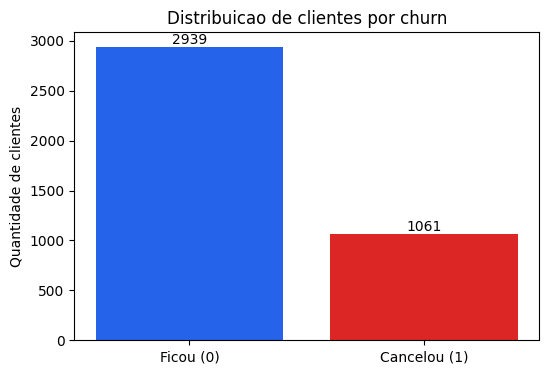

In [31]:
churn_counts = df_clean["Churn"].value_counts().sort_index()
churn_rate = df_clean["Churn"].mean()

print(churn_counts)
print(f"Taxa de churn: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Ficou (0)", "Cancelou (1)"]
ax.bar(labels, churn_counts.values, color=["#2563eb", "#dc2626"])
ax.set_title("Distribuicao de clientes por churn")
ax.set_ylabel("Quantidade de clientes")
ax.bar_label(ax.containers[0])
plt.show()

## 5. Estatisticas descritivas

As estatisticas ajudam a entender escala, dispersao e comportamento das variaveis numericas.

In [32]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


## 6. Comparacao entre clientes que ficaram e cancelaram

A comparacao por grupos mostra quais variaveis mudam mais entre clientes com `Churn = 0` e `Churn = 1`.

In [33]:
features_comparacao = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Age",
    "Contract_period",
    "Month_to_end_contract",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
]

group_means = df_clean.groupby("Churn")[features_comparacao].mean().T
group_means.columns = ["Ficou (0)", "Cancelou (1)"]
group_means.round(2)

,Ficou (0),Cancelou (1)
Lifetime,4.71,0.99
Avg_class_frequency_current_month,2.03,1.04
Age,29.98,26.99
Contract_period,5.75,1.73
Month_to_end_contract,5.28,1.66
Avg_class_frequency_total,2.02,1.47
Avg_additional_charges_total,158.45,115.08


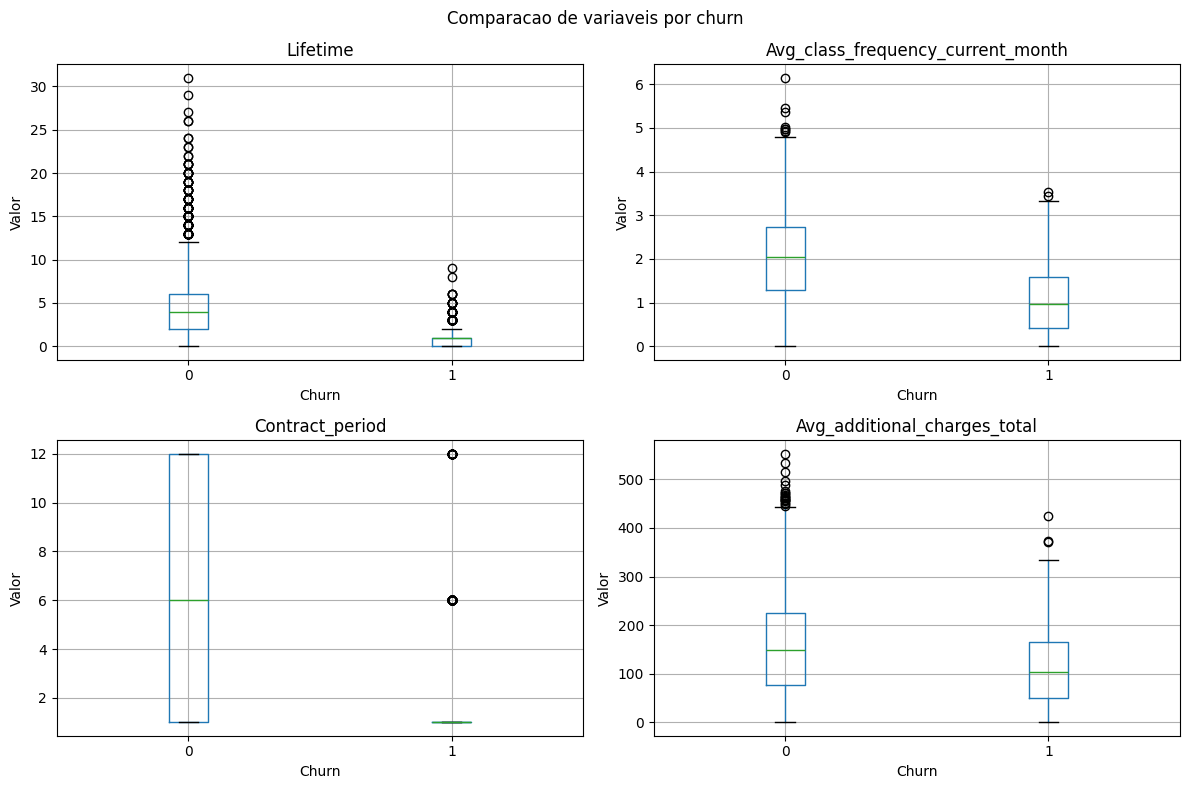

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

plot_features = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Contract_period",
    "Avg_additional_charges_total",
]

for ax, feature in zip(axes, plot_features):
    df_clean.boxplot(column=feature, by="Churn", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Churn")
    ax.set_ylabel("Valor")

plt.suptitle("Comparacao de variaveis por churn")
plt.tight_layout()
plt.show()

## 7. Variaveis categoricas/binarias

As variaveis binarias ajudam a observar diferencas de comportamento em grupos como aulas em grupo, indicacao e proximidade da academia.

In [35]:
binary_features = ["Group_visits", "Promo_friends", "Partner", "Near_Location"]

binary_churn = []
for feature in binary_features:
    rates = df_clean.groupby(feature)["Churn"].mean().rename("churn_rate")
    for value, rate in rates.items():
        binary_churn.append({"feature": feature, "valor": value, "churn_rate": rate})

pd.DataFrame(binary_churn).round(3)

,feature,valor,churn_rate
0,Group_visits,0,0.330
1,Group_visits,1,0.173
2,Promo_friends,0,0.313
3,Promo_friends,1,0.158
4,Partner,0,0.333
5,Partner,1,0.194
6,Near_Location,0,0.397
7,Near_Location,1,0.241


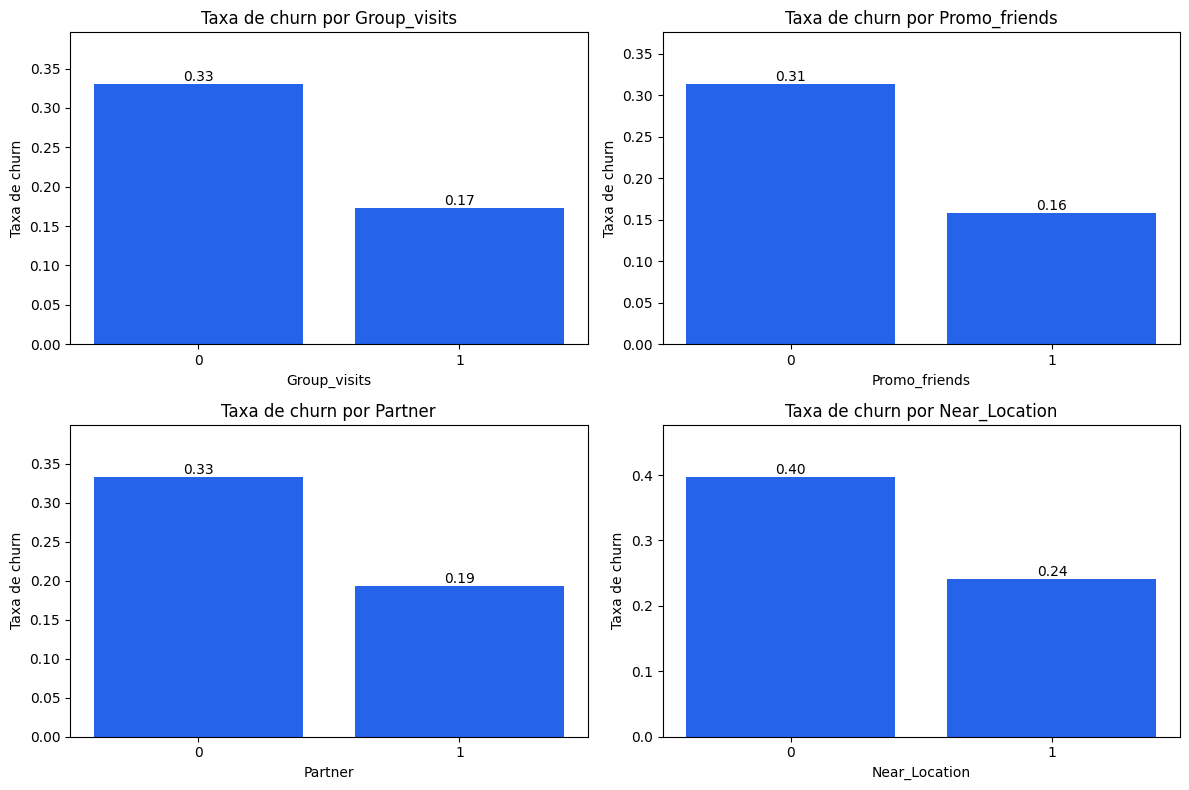

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, binary_features):
    rates = df_clean.groupby(feature)["Churn"].mean().sort_index()
    ax.bar(rates.index.astype(str), rates.values, color="#2563eb")
    ax.set_title(f"Taxa de churn por {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Taxa de churn")
    ax.set_ylim(0, max(rates.max() * 1.2, 0.1))
    ax.bar_label(ax.containers[0], fmt="%.2f")

plt.tight_layout()
plt.show()

## 8. Correlacao com churn e selecao de features

A correlacao e usada aqui como uma analise inicial para orientar a selecao de features. Variaveis com correlacao proxima de zero tendem a contribuir pouco nesta primeira versao.

In [37]:
corr = df_clean.corr(numeric_only=True)["Churn"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_df = corr.drop("Churn").to_frame("correlacao_com_churn")
corr_df

,correlacao_com_churn
Lifetime,-0.438220
Avg_class_frequency_current_month,-0.412348
Age,-0.404735
Contract_period,-0.389984
Month_to_end_contract,-0.381393
Avg_class_frequency_total,-0.249715
Avg_additional_charges_total,-0.198697
Group_visits,-0.175325
Promo_friends,-0.162233
Partner,-0.157986


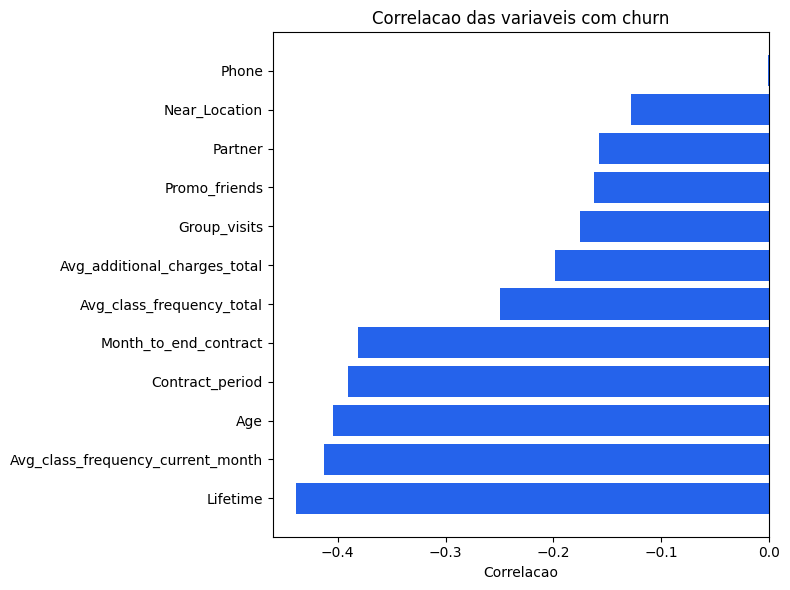

In [38]:
top_corr = corr_df.head(12).sort_values("correlacao_com_churn")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#dc2626" if value > 0 else "#2563eb" for value in top_corr["correlacao_com_churn"]]
ax.barh(top_corr.index, top_corr["correlacao_com_churn"], color=colors)
ax.set_title("Correlacao das variaveis com churn")
ax.set_xlabel("Correlacao")
plt.tight_layout()
plt.show()

In [39]:
features_modelo = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Age",
    "Contract_period",
    "Month_to_end_contract",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
    "Group_visits",
    "Promo_friends",
    "Partner",
    "Near_Location",
]

descartadas = [col for col in ["gender", "Phone"] if col in df_clean.columns]

print("Features usadas no modelo:")
print(features_modelo)
print("\nFeatures descartadas por baixa relacao inicial com churn:")
print(descartadas)

Features usadas no modelo:
['Lifetime', 'Avg_class_frequency_current_month', 'Age', 'Contract_period', 'Month_to_end_contract', 'Avg_class_frequency_total', 'Avg_additional_charges_total', 'Group_visits', 'Promo_friends', 'Partner', 'Near_Location']

Features descartadas por baixa relacao inicial com churn:
['gender', 'Phone']


## 9. Conclusoes da EDA

- A base permite treinar uma primeira versao funcional de modelo de churn.
- `Churn` e a variavel alvo e representa clientes que cancelaram.
- Variaveis como tempo como cliente, frequencia recente, contrato e meses ate o vencimento aparecem como sinais relevantes.
- `gender` e `Phone` foram deixadas fora desta primeira versao por baixa relacao inicial com churn.
- A EDA suporta a arquitetura da Semana 5: upload do CSV, treino do RandomForest no backend e inferencia pela interface web.

## 10. Features derivadas do case

O documento de entregáveis pede variáveis derivadas para capturar queda de engajamento e segmentos de risco. As três principais são:

- `ratio_freq_atual_vs_lifetime`: compara frequência atual com frequência histórica;
- `flag_early_user`: marca clientes com até 1 mês de relacionamento;
- `flag_sleeping_dog`: marca clientes antigos com frequência atual muito baixa.

In [40]:
df_eda = df_clean.copy()

# Evita divisão por zero quando o histórico de frequência for igual a 0.
df_eda["ratio_freq_atual_vs_lifetime"] = (
    df_eda["Avg_class_frequency_current_month"]
    / df_eda["Avg_class_frequency_total"].replace(0, np.nan)
).fillna(0)

df_eda["flag_early_user"] = (df_eda["Lifetime"] <= 1).astype(int)
df_eda["flag_sleeping_dog"] = (
    (df_eda["Lifetime"] >= 6)
    & (df_eda["Avg_class_frequency_current_month"] < 1)
).astype(int)

df_eda[[
    "ratio_freq_atual_vs_lifetime",
    "flag_early_user",
    "flag_sleeping_dog",
    "Churn",
]].groupby("Churn").mean().round(3)

,ratio_freq_atual_vs_lifetime,flag_early_user,flag_sleeping_dog
Churn,,,
0,0.983,0.175,0.052
1,0.646,0.770,0.004


## 11. Visualizações obrigatórias

As visualizações abaixo reforçam a leitura executiva da base: proporção de churn, comparação por tempo de contrato, queda de frequência, perfil por idade/lifetime e mapa de correlação com as variáveis originais e derivadas.

/var/folders/4_/tzjfkk7x71nc4vnpmq3q23bh0000gn/T/ipykernel_13598/1603415783.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(box_data, labels=["Ficou", "Cancelou"], patch_artist=True)


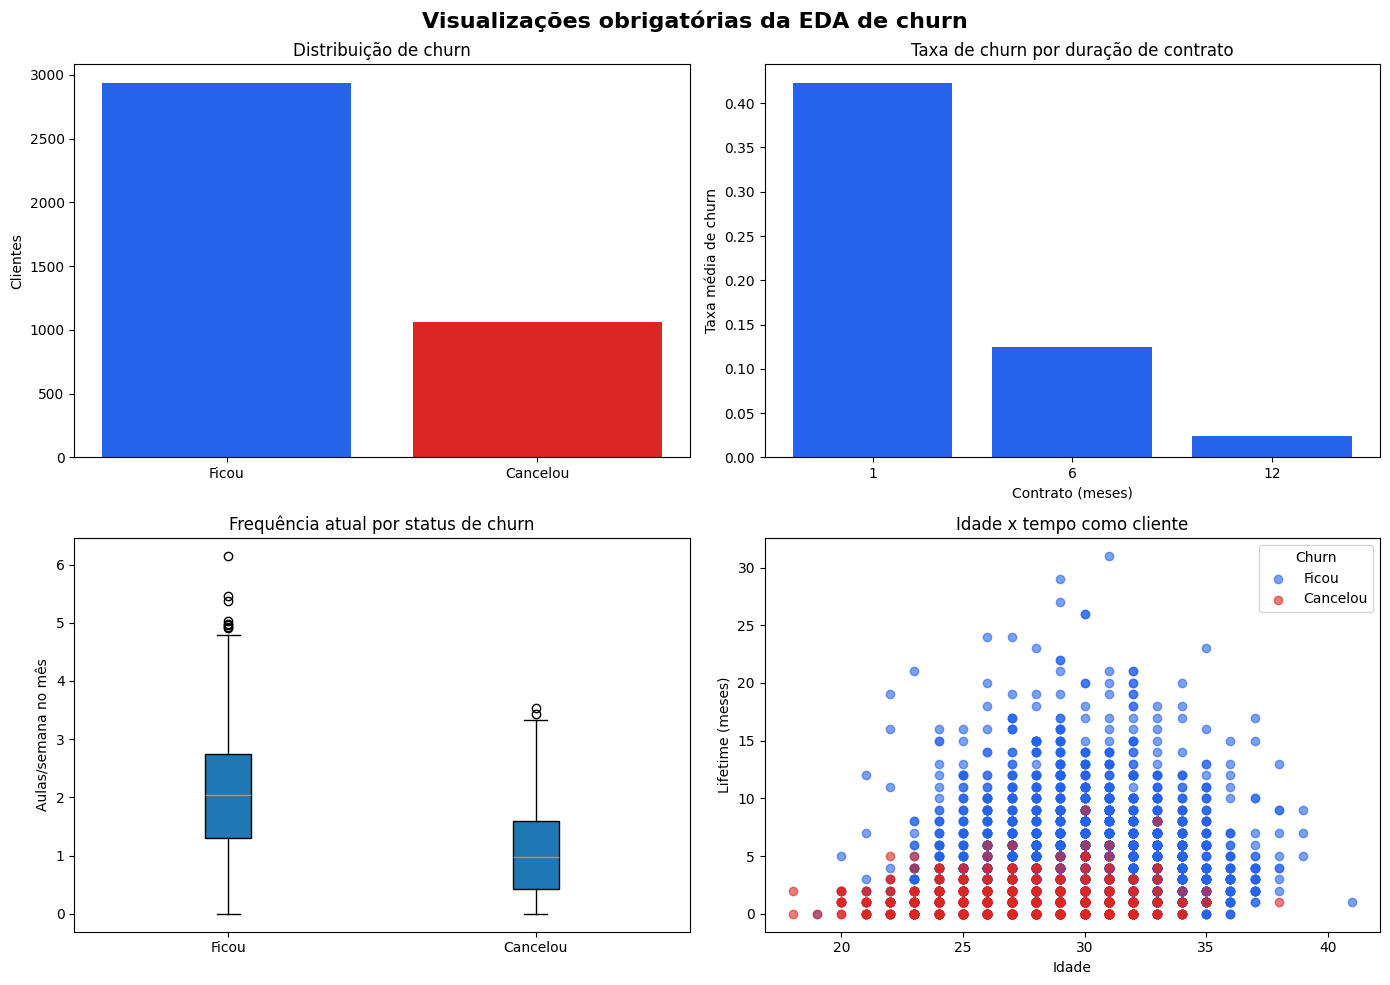

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Visualizações obrigatórias da EDA de churn", fontsize=16, fontweight="bold")

churn_counts = df_eda["Churn"].value_counts().sort_index()
axes[0, 0].bar(["Ficou", "Cancelou"], churn_counts.values, color=["#2563eb", "#dc2626"])
axes[0, 0].set_title("Distribuição de churn")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Clientes")

contract_churn = df_eda.groupby("Contract_period")["Churn"].mean().sort_index()
axes[0, 1].bar(contract_churn.index.astype(str), contract_churn.values, color="#2563eb")
axes[0, 1].set_title("Taxa de churn por duração de contrato")
axes[0, 1].set_xlabel("Contrato (meses)")
axes[0, 1].set_ylabel("Taxa média de churn")

box_data = [
    df_eda.loc[df_eda["Churn"] == 0, "Avg_class_frequency_current_month"],
    df_eda.loc[df_eda["Churn"] == 1, "Avg_class_frequency_current_month"],
]
axes[1, 0].boxplot(box_data, labels=["Ficou", "Cancelou"], patch_artist=True)
axes[1, 0].set_title("Frequência atual por status de churn")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Aulas/semana no mês")

for churn_value, color, label in [(0, "#2563eb", "Ficou"), (1, "#dc2626", "Cancelou")]:
    subset = df_eda[df_eda["Churn"] == churn_value]
    axes[1, 1].scatter(subset["Age"], subset["Lifetime"], alpha=0.6, color=color, label=label)
axes[1, 1].set_title("Idade x tempo como cliente")
axes[1, 1].set_xlabel("Idade")
axes[1, 1].set_ylabel("Lifetime (meses)")
axes[1, 1].legend(title="Churn")

plt.tight_layout()
plt.show()

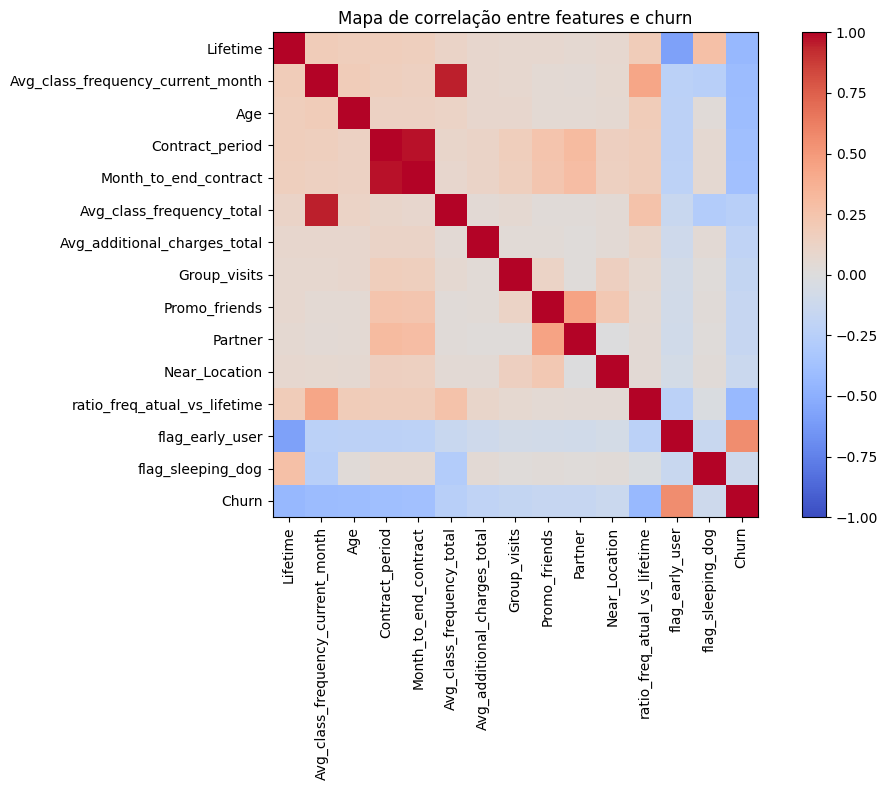

,correlacao_com_churn
flag_early_user,0.558
Lifetime,-0.438
ratio_freq_atual_vs_lifetime,-0.434
Avg_class_frequency_current_month,-0.412
Age,-0.405
Contract_period,-0.390
Month_to_end_contract,-0.381
Avg_class_frequency_total,-0.250
Avg_additional_charges_total,-0.199
Group_visits,-0.175


In [42]:
features_para_correlacao = FEATURES + [
    "ratio_freq_atual_vs_lifetime",
    "flag_early_user",
    "flag_sleeping_dog",
    "Churn",
]

corr_matrix = df_eda[features_para_correlacao].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12, 8))
heatmap = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Mapa de correlação entre features e churn")
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

correlacao_churn = (
    corr_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

correlacao_churn.head(10).to_frame("correlacao_com_churn").round(3)

In [43]:
segmentos = pd.DataFrame({
    "segmento": [
        "Usuários novos",
        "Sleeping dogs",
        "Contrato curto",
        "Baixa frequência atual",
        "Sem visitas em grupo",
    ],
    "clientes": [
        int(df_eda["flag_early_user"].sum()),
        int(df_eda["flag_sleeping_dog"].sum()),
        int((df_eda["Contract_period"] <= 1).sum()),
        int((df_eda["Avg_class_frequency_current_month"] < 1).sum()),
        int((df_eda["Group_visits"] == 0).sum()),
    ],
    "churn_rate": [
        df_eda.loc[df_eda["flag_early_user"] == 1, "Churn"].mean(),
        df_eda.loc[df_eda["flag_sleeping_dog"] == 1, "Churn"].mean(),
        df_eda.loc[df_eda["Contract_period"] <= 1, "Churn"].mean(),
        df_eda.loc[df_eda["Avg_class_frequency_current_month"] < 1, "Churn"].mean(),
        df_eda.loc[df_eda["Group_visits"] == 0, "Churn"].mean(),
    ],
})
segmentos["churn_rate"] = segmentos["churn_rate"].fillna(0).round(3)
segmentos.sort_values("churn_rate", ascending=False)

,segmento,clientes,churn_rate
0,Usuários novos,1330,0.614
3,Baixa frequência atual,1043,0.516
2,Contrato curto,2207,0.423
4,Sem visitas em grupo,2351,0.330
1,Sleeping dogs,157,0.025


## 12. Leitura executiva das features derivadas

As features derivadas ajudam a traduzir comportamento em ação:

- queda na frequência recente indica perda de hábito e deve acionar contato preventivo;
- clientes no início do relacionamento precisam de onboarding ativo;
- clientes antigos com baixa frequência são bons candidatos a campanhas de reativação;
- contratos curtos concentram maior vulnerabilidade e merecem incentivo para migração de plano;
- ausência de aulas em grupo sugere menor vínculo social com a academia.

## 13. Visualizações obrigatórias complementares da Semana 5

Este bloco complementa a EDA com as visualizações mais literais do documento de entregáveis:

- scatter de `Avg_class_frequency_total` versus `Avg_class_frequency_current_month`, colorido por churn;
- curva de sobrevivência aproximada por tempo de assinatura (`Lifetime`), calculada diretamente com pandas;
- distribuição de churn por coorte operacional de tempo de relacionamento.

Observação: a base não contém data de entrada/calendário, então a coorte de entrada foi representada por faixas de `Lifetime`, que é a proxy disponível para tempo de relacionamento.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Visualizações obrigatórias complementares", fontsize=15, fontweight="bold")

# (e) Scatter freq_lifetime x freq_atual colorido por churn.
for churn_value, color, label in [(0, "#2563eb", "Ficou"), (1, "#dc2626", "Cancelou")]:
    subset = df_eda[df_eda["Churn"] == churn_value]
    axes[0].scatter(
        subset["Avg_class_frequency_total"],
        subset["Avg_class_frequency_current_month"],
        alpha=0.45,
        s=18,
        color=color,
        label=label,
    )
axes[0].axline((0, 0), slope=1, color="#64748b", linestyle="--", linewidth=1)
axes[0].set_title("Freq. histórica x freq. atual")
axes[0].set_xlabel("Frequência histórica semanal")
axes[0].set_ylabel("Frequência no mês atual")
axes[0].legend(title="Churn")

# (b) Curva de sobrevivência aproximada por Lifetime.
survival_rows = []
survival_probability = 1.0
for lifetime in sorted(df_eda["Lifetime"].unique()):
    at_risk = df_eda[df_eda["Lifetime"] >= lifetime]
    events = df_eda[(df_eda["Lifetime"] == lifetime) & (df_eda["Churn"] == 1)]
    hazard = len(events) / len(at_risk) if len(at_risk) else 0
    survival_probability *= 1 - hazard
    survival_rows.append({
        "Lifetime": lifetime,
        "survival_probability": survival_probability,
        "at_risk": len(at_risk),
        "events": len(events),
    })

survival_df = pd.DataFrame(survival_rows)
axes[1].plot(
    survival_df["Lifetime"],
    survival_df["survival_probability"],
    marker="o",
    color="#2563eb",
)
axes[1].set_title("Sobrevivência aproximada por Lifetime")
axes[1].set_xlabel("Lifetime (meses)")
axes[1].set_ylabel("Probabilidade de permanência")
axes[1].set_ylim(0, 1.05)

# (f) Distribuição de churn por coorte operacional de entrada.
cohort_bins = [-1, 1, 3, 6, 12, float("inf")]
cohort_labels = ["0-1 mês", "2-3 meses", "4-6 meses", "7-12 meses", "13+ meses"]
df_eda["cohort_lifetime"] = pd.cut(
    df_eda["Lifetime"],
    bins=cohort_bins,
    labels=cohort_labels,
    include_lowest=True,
)
cohort_churn = df_eda.groupby("cohort_lifetime", observed=False)["Churn"].mean().fillna(0)
axes[2].bar(cohort_churn.index.astype(str), cohort_churn.values, color="#2563eb")
axes[2].set_title("Churn por coorte de relacionamento")
axes[2].set_xlabel("Coorte por Lifetime")
axes[2].set_ylabel("Taxa de churn")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

survival_df.head(), cohort_churn.to_frame("churn_rate").round(3)

## 14. Segmentação diagnóstica do case

O documento pede três segmentos executivos para apoiar decisão de retenção. Abaixo calculamos esses grupos com as variáveis disponíveis na base:

- `early_droppers`: clientes com `Lifetime <= 1` que já cancelaram;
- `sleeping_dogs`: clientes antigos (`Lifetime > 6`) com frequência atual muito baixa (`< 0,5`);
- `usuarios_anuais_uso_zero`: clientes de contrato anual com frequência atual igual a zero.

Como a base não traz mensalidade ou LTV contratual, o pipeline financeiro é apresentado com uma premissa explícita de ticket mensal ajustável.

In [ ]:
ticket_mensal_estimado = 150

segmentos_case = {
    "early_droppers": df_eda[(df_eda["Lifetime"] <= 1) & (df_eda["Churn"] == 1)],
    "sleeping_dogs": df_eda[(df_eda["Lifetime"] > 6) & (df_eda["Avg_class_frequency_current_month"] < 0.5)],
    "usuarios_anuais_uso_zero": df_eda[(df_eda["Contract_period"] == 12) & (df_eda["Avg_class_frequency_current_month"] == 0)],
}

total_churn = max(int((df_eda["Churn"] == 1).sum()), 1)
total_base = max(len(df_eda), 1)

segmentos_diagnosticos = pd.DataFrame([
    {
        "segmento": "early_droppers",
        "clientes": len(segmentos_case["early_droppers"]),
        "percentual_referencia": len(segmentos_case["early_droppers"]) / total_churn,
        "referencia": "% do churn total",
        "acao_recomendada": "onboarding intensivo nos primeiros 30 dias",
    },
    {
        "segmento": "sleeping_dogs",
        "clientes": len(segmentos_case["sleeping_dogs"]),
        "percentual_referencia": len(segmentos_case["sleeping_dogs"]) / total_base,
        "referencia": "% da base total",
        "acao_recomendada": "reativação cuidadosa, evitando contato excessivo",
    },
    {
        "segmento": "usuarios_anuais_uso_zero",
        "clientes": len(segmentos_case["usuarios_anuais_uso_zero"]),
        "percentual_referencia": len(segmentos_case["usuarios_anuais_uso_zero"]) / total_base,
        "referencia": "% da base total",
        "acao_recomendada": "monitorar vencimento e criar oferta de retomada",
    },
])

segmentos_diagnosticos["percentual_referencia"] = (
    segmentos_diagnosticos["percentual_referencia"] * 100
).round(1).astype(str) + "%"

pipeline_churn_diferido = (
    len(segmentos_case["usuarios_anuais_uso_zero"])
    * ticket_mensal_estimado
    * 12
)

print(f"Premissa de ticket mensal: US$ {ticket_mensal_estimado}")
print(f"Pipeline financeiro estimado em usuários anuais com uso zero: US$ {pipeline_churn_diferido:,.0f}")
segmentos_diagnosticos